# 03 · Experiments: Model Selection and Application Performance
**ISOM5240 Group Project — Oriental Horizon Hotel Business**

This notebook runs the two experiments required by the project brief:

1. **Model selection.** For each task, compare the models on the same test set using
   **accuracy** (plus macro-F1) and **runtime**:
   * a pre-trained model used *without* fine-tuning (baseline);
   * our two fine-tuned candidates (from Notebooks 01 and 02).
2. **Application performance.** Run the two final models exactly as the Streamlit app does
   (CPU, same settings) and measure their **accuracy**.

All results are written to `Experimental_results.xlsx`, with charts for the report.

⚠️ **Runtime → Change runtime type → T4 GPU** (the accuracy tests use the GPU; runtime is
measured on the CPU to match Streamlit Cloud). It takes about 20 minutes.

## 1. Install and import libraries

In [ ]:
%pip install -q transformers==5.16.0 accelerate scikit-learn openpyxl huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 44.1 MB/s eta 0:00:00


In [ ]:
import os
import time

import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from transformers import pipeline, set_seed

GPU = 0 if torch.cuda.is_available() else -1
print("GPU available:", torch.cuda.is_available())

GPU available: True


## 2. Configuration

In [ ]:
HF_USERNAME = "ludanzhang54"
DATA_DIR = f"hf://datasets/{HF_USERNAME}/oriental-horizon-hotel-reviews"

MAX_LENGTH = 256
RUNTIME_SAMPLES = 100      # reviews used to time each model on the CPU
APP_TEST_SAMPLES = 300     # reviews per task for the application-level test
SEED = 42
set_seed(SEED)

# Every model compared in the experiments.
# "kind" says how to turn the model's output into one of our labels.
EXPERIMENTS = {
    "sentiment": [
        {"model": "nlptown/bert-base-multilingual-uncased-sentiment",
         "approach": "Pre-trained, no fine-tuning (1-5 stars mapped to 3 classes)", "kind": "stars"},
        {"model": f"{HF_USERNAME}/oh-sentiment-distilbert",
         "approach": "Fine-tuned distilbert-base-uncased", "kind": "direct"},
        {"model": f"{HF_USERNAME}/oh-sentiment-distilroberta",
         "approach": "Fine-tuned distilroberta-base", "kind": "direct"},
    ],
    "segment": [
        {"model": "facebook/bart-large-mnli",
         "approach": "Pre-trained zero-shot classification, no fine-tuning", "kind": "zero-shot"},
        {"model": f"{HF_USERNAME}/oh-segment-distilbert",
         "approach": "Fine-tuned distilbert-base-uncased", "kind": "direct"},
        {"model": f"{HF_USERNAME}/oh-segment-distilroberta",
         "approach": "Fine-tuned distilroberta-base", "kind": "direct"},
    ],
}

# Final models used by the Streamlit app (uploaded by Notebooks 01 and 02).
APP_MODELS = {
    "sentiment": f"{HF_USERNAME}/oh-review-sentiment",
    "segment": f"{HF_USERNAME}/oh-guest-segment",
}

# Descriptions used by the zero-shot baseline for each segment.
ZERO_SHOT_LABELS = {
    "a business trip": "business",
    "a leisure trip or holiday": "leisure",
}

## 3. Load the test sets

In [ ]:
test_sets = {task: pd.read_csv(f"{DATA_DIR}/{task}_test.csv") for task in EXPERIMENTS}
for task, df in test_sets.items():
    print(f"{task:<10} {len(df):,} test reviews | {df['label'].value_counts().to_dict()}")

sentiment  4,500 test reviews | {'positive': 1500, 'negative': 1500, 'neutral': 1500}
segment    3,000 test reviews | {'leisure': 1500, 'business': 1500}


## 4. Helper functions
Every model is wrapped in a Hugging Face `pipeline`. A small adapter turns each kind of output
into one of our labels:
* **stars**: the nlptown model predicts 1–5 stars → 1–2 = negative, 3 = neutral, 4–5 = positive;
* **zero-shot**: BART-MNLI picks the best-matching segment description;
* **direct**: our fine-tuned models already predict our labels.

In [ ]:
def stars_to_sentiment(star_label):
    """'4 stars' -> 'positive'."""
    stars = int(star_label[0])
    return "negative" if stars <= 2 else "neutral" if stars == 3 else "positive"


def load_pipeline(config, device):
    """Create the Hugging Face pipeline for one experiment."""
    task = "zero-shot-classification" if config["kind"] == "zero-shot" else "text-classification"
    return pipeline(task, model=config["model"], device=device)


def predict(pipe, config, texts, batch_size=32):
    """Predict one of our labels for every text."""
    if config["kind"] == "zero-shot":
        outputs = pipe(
            texts,
            candidate_labels=list(ZERO_SHOT_LABELS),
            hypothesis_template="This hotel review was written by a guest on {}.",
            batch_size=batch_size,
        )
        return [ZERO_SHOT_LABELS[output["labels"][0]] for output in outputs]

    outputs = pipe(texts, batch_size=batch_size, truncation=True, max_length=MAX_LENGTH)
    labels = [output["label"] for output in outputs]
    return [stars_to_sentiment(label) for label in labels] if config["kind"] == "stars" else labels


def time_on_cpu(config, texts):
    """Average milliseconds per review on the CPU, one review at a time (like the app)."""
    cpu_pipe = load_pipeline(config, device=-1)
    predict(cpu_pipe, config, texts[:5], batch_size=1)      # warm-up run, not timed
    start = time.perf_counter()
    predict(cpu_pipe, config, texts, batch_size=1)
    return (time.perf_counter() - start) / len(texts) * 1000

## 5. Experiment 1: model selection (accuracy and runtime)
Accuracy is measured on the **full test set**. Runtime is measured on the CPU with
`RUNTIME_SAMPLES` reviews, which matches how the app runs on Streamlit Cloud.

In [ ]:
selection_rows, report_rows, confusion_rows, predictions = [], [], [], {}

for task, configs in EXPERIMENTS.items():
    df = test_sets[task]
    texts, truth = df["text"].tolist(), df["label"].tolist()
    labels = sorted(df["label"].unique())

    for config in configs:
        print(f"[{task}] {config['model']} ...")
        pipe = load_pipeline(config, device=GPU)
        predicted = predict(pipe, config, texts)
        predictions[(task, config["model"])] = predicted
        ms_per_review = time_on_cpu(config, texts[:RUNTIME_SAMPLES])

        selection_rows.append({
            "task": task,
            "model": config["model"],
            "approach": config["approach"],
            "test_samples": len(texts),
            "accuracy": round(accuracy_score(truth, predicted), 4),
            "macro_f1": round(f1_score(truth, predicted, average="macro"), 4),
            "cpu_ms_per_review": round(ms_per_review, 1),
            "parameters_millions": round(pipe.model.num_parameters() / 1e6, 1),
        })

        report = classification_report(truth, predicted, labels=labels, output_dict=True, zero_division=0)
        for label in labels:
            report_rows.append({"task": task, "model": config["model"], "label": label,
                                **{k: round(v, 4) for k, v in report[label].items()}})

        matrix = confusion_matrix(truth, predicted, labels=labels)
        for true_label, row in zip(labels, matrix):
            confusion_rows.append({"task": task, "model": config["model"], "true_label": true_label,
                                   **{f"predicted_{label}": int(n) for label, n in zip(labels, row)}})
        del pipe
        torch.cuda.empty_cache()

selection_df = pd.DataFrame(selection_rows)
selection_df

[sentiment] nlptown/bert-base-multilingual-uncased-sentiment ...


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  669MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/388 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

,task,model,approach,test_samples,accuracy,macro_f1,cpu_ms_per_review,parameters_millions
0,sentiment,nlptown/bert-base-multilingual-uncased-sentiment,"Pre-trained, no fine-tuning (1-5 stars mapped ...",4500,0.6282,0.6046,149.1,167.4
1,sentiment,ludanzhang54/oh-sentiment-distilbert,Fine-tuned distilbert-base-uncased,4500,0.7496,0.7503,107.1,67.0
2,sentiment,ludanzhang54/oh-sentiment-distilroberta,Fine-tuned distilroberta-base,4500,0.7593,0.7597,77.7,82.1
3,segment,facebook/bart-large-mnli,"Pre-trained zero-shot classification, no fine-...",3000,0.5537,0.4615,1692.6,407.3
4,segment,ludanzhang54/oh-segment-distilbert,Fine-tuned distilbert-base-uncased,3000,0.7207,0.7206,83.3,67.0
5,segment,ludanzhang54/oh-segment-distilroberta,Fine-tuned distilroberta-base,3000,0.7197,0.7196,75.2,82.1


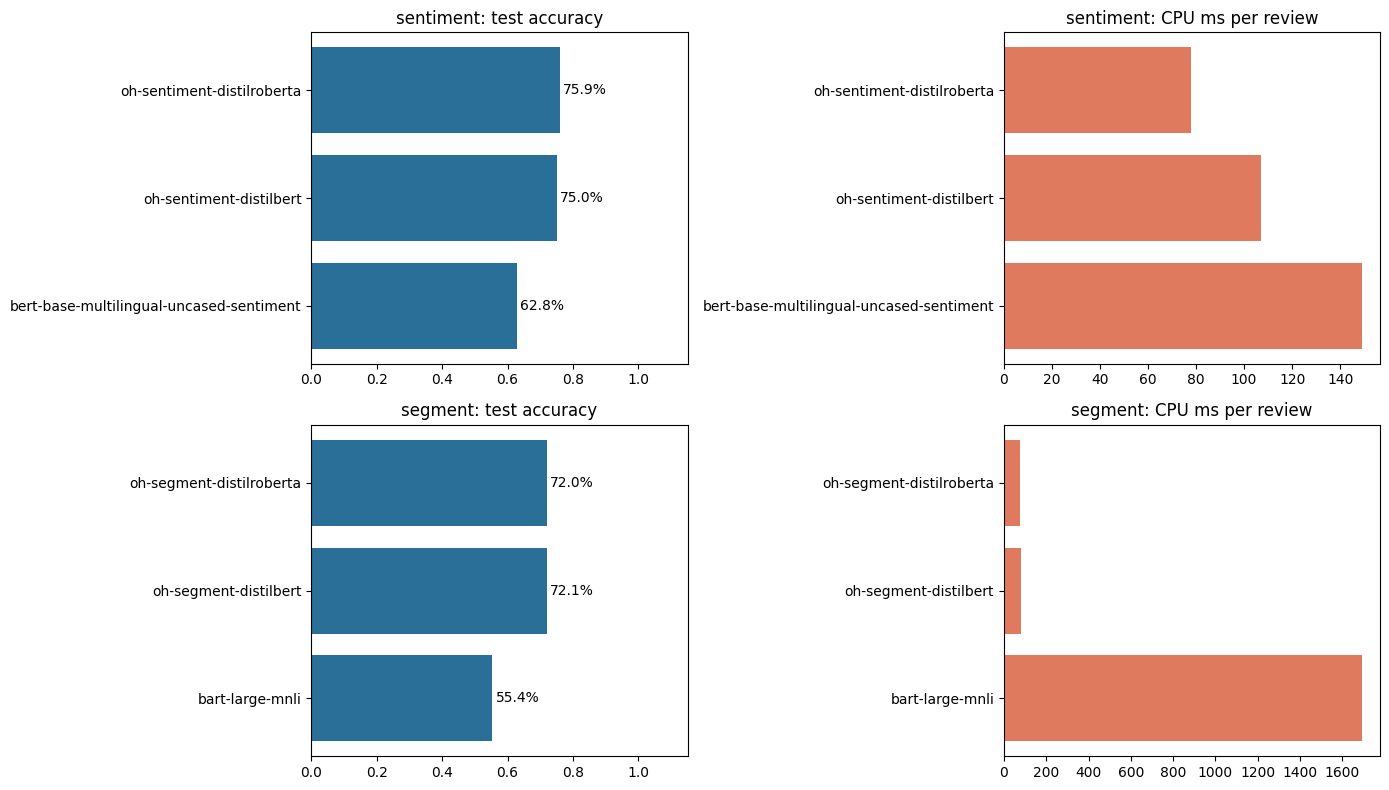

In [ ]:
# Charts for the report: accuracy and CPU runtime of every model.
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for row, task in enumerate(EXPERIMENTS):
    task_df = selection_df[selection_df["task"] == task]
    names = [name.split("/")[-1] for name in task_df["model"]]
    axes[row, 0].barh(names, task_df["accuracy"], color="#2a6f97")
    axes[row, 0].set_title(f"{task}: test accuracy")
    axes[row, 0].set_xlim(0, 1.15)
    for i, value in enumerate(task_df["accuracy"]):
        axes[row, 0].text(value + 0.01, i, f"{value:.1%}", va="center")
    axes[row, 1].barh(names, task_df["cpu_ms_per_review"], color="#e07a5f")
    axes[row, 1].set_title(f"{task}: CPU ms per review")
plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/model_selection.png", dpi=150)
plt.show()

## 6. Experiment 2: application performance
The two final models are run **exactly as in the Streamlit app**: on the CPU, through a
`text-classification` pipeline with the same truncation. We use `APP_TEST_SAMPLES` random test
reviews per task. The app's *Accuracy check* tab draws the same sample (same seed), so its
number on Streamlit Cloud should match the one here.

In [ ]:
app_rows, error_rows = [], []
for task, model_id in APP_MODELS.items():
    sample = test_sets[task].sample(n=min(APP_TEST_SAMPLES, len(test_sets[task])), random_state=SEED)
    config = {"model": model_id, "kind": "direct"}
    app_pipe = load_pipeline(config, device=-1)

    start = time.perf_counter()
    predicted = predict(app_pipe, config, sample["text"].tolist(), batch_size=8)
    seconds = time.perf_counter() - start

    app_rows.append({
        "task": task,
        "app_model": model_id,
        "test_samples": len(sample),
        "accuracy": round(accuracy_score(sample["label"], predicted), 4),
        "macro_f1": round(f1_score(sample["label"], predicted, average="macro"), 4),
        "total_seconds_cpu": round(seconds, 1),
    })
    wrong = sample.assign(predicted=predicted).query("label != predicted").head(10)
    for _, r in wrong.iterrows():
        error_rows.append({"task": task, "true_label": r["label"], "predicted": r["predicted"],
                           "review": r["text"][:300]})

app_df = pd.DataFrame(app_rows)
app_df

config.json:   0%|          | 0.00/822 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

,task,app_model,test_samples,accuracy,macro_f1,total_seconds_cpu
0,sentiment,ludanzhang54/oh-review-sentiment,300,0.7333,0.7327,26.9
1,segment,ludanzhang54/oh-guest-segment,300,0.7433,0.7432,31.9


### Error analysis
Examples the final models got wrong. They help explain the models' limits in the report.

In [ ]:
errors_df = pd.DataFrame(error_rows)
pd.set_option("display.max_colwidth", 200)
errors_df

,task,true_label,predicted,review
0,sentiment,negative,neutral,The room was large wide and good Wifi was bad Hausekeeping was not enough Location was not so close to the city center But you can easily reach there by public transportation
1,sentiment,positive,negative,the elevator does not reach all floors and the enterance to the hotel not so conveinance with a baby
2,sentiment,neutral,negative,The staff were all friendly The food was good in general The hotel itself is very pleasant The sheets on the sofa bed were dirty on arrival I had to make 3 requests to change them The carpet neede...
3,sentiment,positive,neutral,Good size bedroom and bathroom Sometimes lifts not working
4,sentiment,negative,neutral,I liked its staff was just ok Ok ok best There was no room service though it says on the website when we book Also says u will have sofa bed in room but we didn t have it in our room Water comes h...
5,sentiment,positive,neutral,Walking distance to railway station Good breakfast
6,sentiment,positive,neutral,Good disabled and wheelchair facilities step free access to building lifts and room etc Good restaurant in the complex
7,sentiment,positive,neutral,Size of the room and clean
8,sentiment,negative,neutral,Hotel has safety luggage deposit room If compare to price disappointed
9,sentiment,neutral,positive,Bar was lovely beside reception


## 7. Save all results to Excel

In [ ]:
EXCEL_PATH = "results/Experimental_results.xlsx"
with pd.ExcelWriter(EXCEL_PATH) as writer:
    selection_df.to_excel(writer, sheet_name="1_Model_selection", index=False)
    pd.DataFrame(report_rows).to_excel(writer, sheet_name="2_Per_class_results", index=False)
    confusion_df = pd.DataFrame(confusion_rows)
    for task in EXPERIMENTS:
        task_matrix = confusion_df[confusion_df["task"] == task].dropna(axis=1, how="all")
        task_matrix.to_excel(writer, sheet_name=f"3_Confusion_{task}", index=False)
    app_df.to_excel(writer, sheet_name="4_App_performance", index=False)
    errors_df.to_excel(writer, sheet_name="5_Error_examples", index=False)
print("Saved", EXCEL_PATH)

Saved results/Experimental_results.xlsx
